# 1. Cargar YOLO

In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:

print("GPU disponible:", torch.cuda.is_available())


GPU disponible: False


In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Se crea un subset para entrenamiento

In [4]:
YOLO_ROOT = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/yolo_soccer"


In [5]:
import os
from glob import glob

label_dir = os.path.join(YOLO_ROOT, "labels", "train")

ball_imgs = []
player_only_imgs = []

for lbl_path in glob(os.path.join(label_dir, "*.txt")):
    has_ball = False
    has_player = False

    with open(lbl_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(parts[0])
            if cid == 1:
                has_ball = True
            elif cid == 0:
                has_player = True

    img_name = os.path.basename(lbl_path).replace(".txt", ".jpg")

    if has_ball:
        ball_imgs.append(img_name)
    elif has_player:
        player_only_imgs.append(img_name)

len(ball_imgs), len(player_only_imgs)


(20504, 1096)

In [12]:
import random

MAX_TOTAL = 3500

random.shuffle(ball_imgs)
random.shuffle(player_only_imgs)

# 1) tomamos solo una parte de las imágenes con balón
n_ball = min(len(ball_imgs), int(MAX_TOTAL * 0.7))  # 70% con balón
subset_imgs = ball_imgs[:n_ball]

# 2) completamos el resto con solo jugadores (si existen)
restante = MAX_TOTAL - len(subset_imgs)
if restante > 0:
    subset_imgs += player_only_imgs[:restante]

print("Ball usadas:", len(subset_imgs[:n_ball]))
print("Solo jugadores usadas:", max(0, len(subset_imgs) - n_ball))
print("Total subset:", len(subset_imgs))


Ball usadas: 2450
Solo jugadores usadas: 1050
Total subset: 3500


In [7]:
YOLO_IMG_TRAIN = os.path.join(YOLO_ROOT, "images", "train")


subset_train_txt = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/train_subset_cpu.txt"

with open(subset_train_txt, "w") as f:
    for img_name in subset_imgs:
        f.write(f"{YOLO_IMG_TRAIN}/{img_name}\n")

print("Subset de train guardado en:", subset_train_txt)


Subset de train guardado en: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/train_subset_cpu.txt


In [13]:
#import os, random

#YOLO_ROOT = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/yolo_soccer"
val_dir = os.path.join(YOLO_ROOT, "images", "val")

all_val = os.listdir(val_dir)
random.shuffle(all_val)

N_VAL = 500   # por ejemplo 500 (ajústalo: 200–1000 suele estar bien)
subset_val = all_val[:N_VAL]

with open("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/val_subset_cpu.txt", "w") as f:
    for img in subset_val:
        f.write(f"{val_dir}/{img}\n")

print("Val subset:", len(subset_val))


Val subset: 500


In [14]:
yaml_text = f"""
train: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/train_subset_cpu.txt
val: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/val_subset_cpu.txt

nc: 2
names:
  - player
  - ball
"""

with open("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/soccer_cpu.yaml", "w") as f:
    f.write(yaml_text)

print(open("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/soccer_cpu.yaml").read())



train: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/train_subset_cpu.txt
val: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/val_subset_cpu.txt

nc: 2
names:
  - player
  - ball



## Se carga el modelo de YOLO preentrenado

In [15]:
# Cargar modelo base preentrenado en COCO
model = YOLO("yolov8n.pt")



In [16]:
results = model.train(
    data="/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/soccer_cpu.yaml",
    epochs=5,          # MUY pocas épocas para probar pipeline
    imgsz=320,         # baja resolución = gran aceleración
    batch=16,           # no lo subas mucho en CPU
    device="cpu",
    workers=4,         # sube a 2 o 4, depende de tu RAM
    cache=False,       # pon True solo si te sobra RAM
    project="runs_soccer",
    name="yolo_cpu_fast"
)


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/soccer_cpu.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_cpu_fast3, nbs=64, nms=False, opset=None, optimize=False, opt

In [22]:
!zip -r carpeta.zip /content/runs_soccer

  adding: content/runs_soccer/ (stored 0%)
  adding: content/runs_soccer/yolo_cpu_fast3/ (stored 0%)
  adding: content/runs_soccer/yolo_cpu_fast3/BoxP_curve.png (deflated 17%)
  adding: content/runs_soccer/yolo_cpu_fast3/labels.jpg (deflated 34%)
  adding: content/runs_soccer/yolo_cpu_fast3/BoxF1_curve.png (deflated 16%)
  adding: content/runs_soccer/yolo_cpu_fast3/val_batch2_pred.jpg (deflated 9%)
  adding: content/runs_soccer/yolo_cpu_fast3/confusion_matrix_normalized.png (deflated 34%)
  adding: content/runs_soccer/yolo_cpu_fast3/confusion_matrix.png (deflated 33%)
  adding: content/runs_soccer/yolo_cpu_fast3/args.yaml (deflated 51%)
  adding: content/runs_soccer/yolo_cpu_fast3/train_batch2.jpg (deflated 3%)
  adding: content/runs_soccer/yolo_cpu_fast3/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs_soccer/yolo_cpu_fast3/val_batch1_labels.jpg (deflated 9%)
  adding: content/runs_soccer/yolo_cpu_fast3/val_batch1_pred.jpg (deflated 9%)
  adding: content/runs_soccer/yolo_cpu_f

In [23]:
!zip -r sample_data.zip /content/sample_data

  adding: content/sample_data/ (stored 0%)
  adding: content/sample_data/anscombe.json (deflated 83%)
  adding: content/sample_data/README.md (deflated 39%)
  adding: content/sample_data/california_housing_train.csv (deflated 79%)
  adding: content/sample_data/mnist_train_small.csv (deflated 88%)
  adding: content/sample_data/mnist_test.csv (deflated 88%)
  adding: content/sample_data/california_housing_test.csv (deflated 76%)


In [18]:
run_dir ="/content/runs_soccer/yolo_cpu_fast3"
best_weights = f"{run_dir}/weights/best.pt"

model_best = YOLO(best_weights)

metrics = model_best.val(data="/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/soccer_cpu.yaml", split="val")

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 88.4±19.8 MB/s, size: 249.6 KB)
val: Scanning /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/yolo_soccer/labels/val.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 474.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.3it/s 24.1s
                   all        500       7504      0.444      0.405      0.432      0.201
                player        500       7056      0.887       0.81      0.865      0.403
                  ball        438        448          0          0          0          0
Speed: 0.2ms preprocess, 30.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val2


In [19]:
print("mAP@0.5-0.95:", metrics.box.map)      # mAP50-95 global
print("mAP@0.5:", metrics.box.map50)         # mAP50 global
print("Precisión media:", metrics.box.mp)    # mean precision
print("Recall medio:", metrics.box.mr)       # mean recall

# mAP por clase (en el orden de names: [player, ball])
for i, cls_map in enumerate(metrics.box.maps):
    nombre = ["player", "ball"][i]
    print(f"mAP@0.5-0.95 ({nombre}): {cls_map:.4f}")

mAP@0.5-0.95: 0.2014360200334159
mAP@0.5: 0.43228175711783623
Precisión media: 0.44373339885064433
Recall medio: 0.40515469708645474
mAP@0.5-0.95 (player): 0.4029
mAP@0.5-0.95 (ball): 0.0000


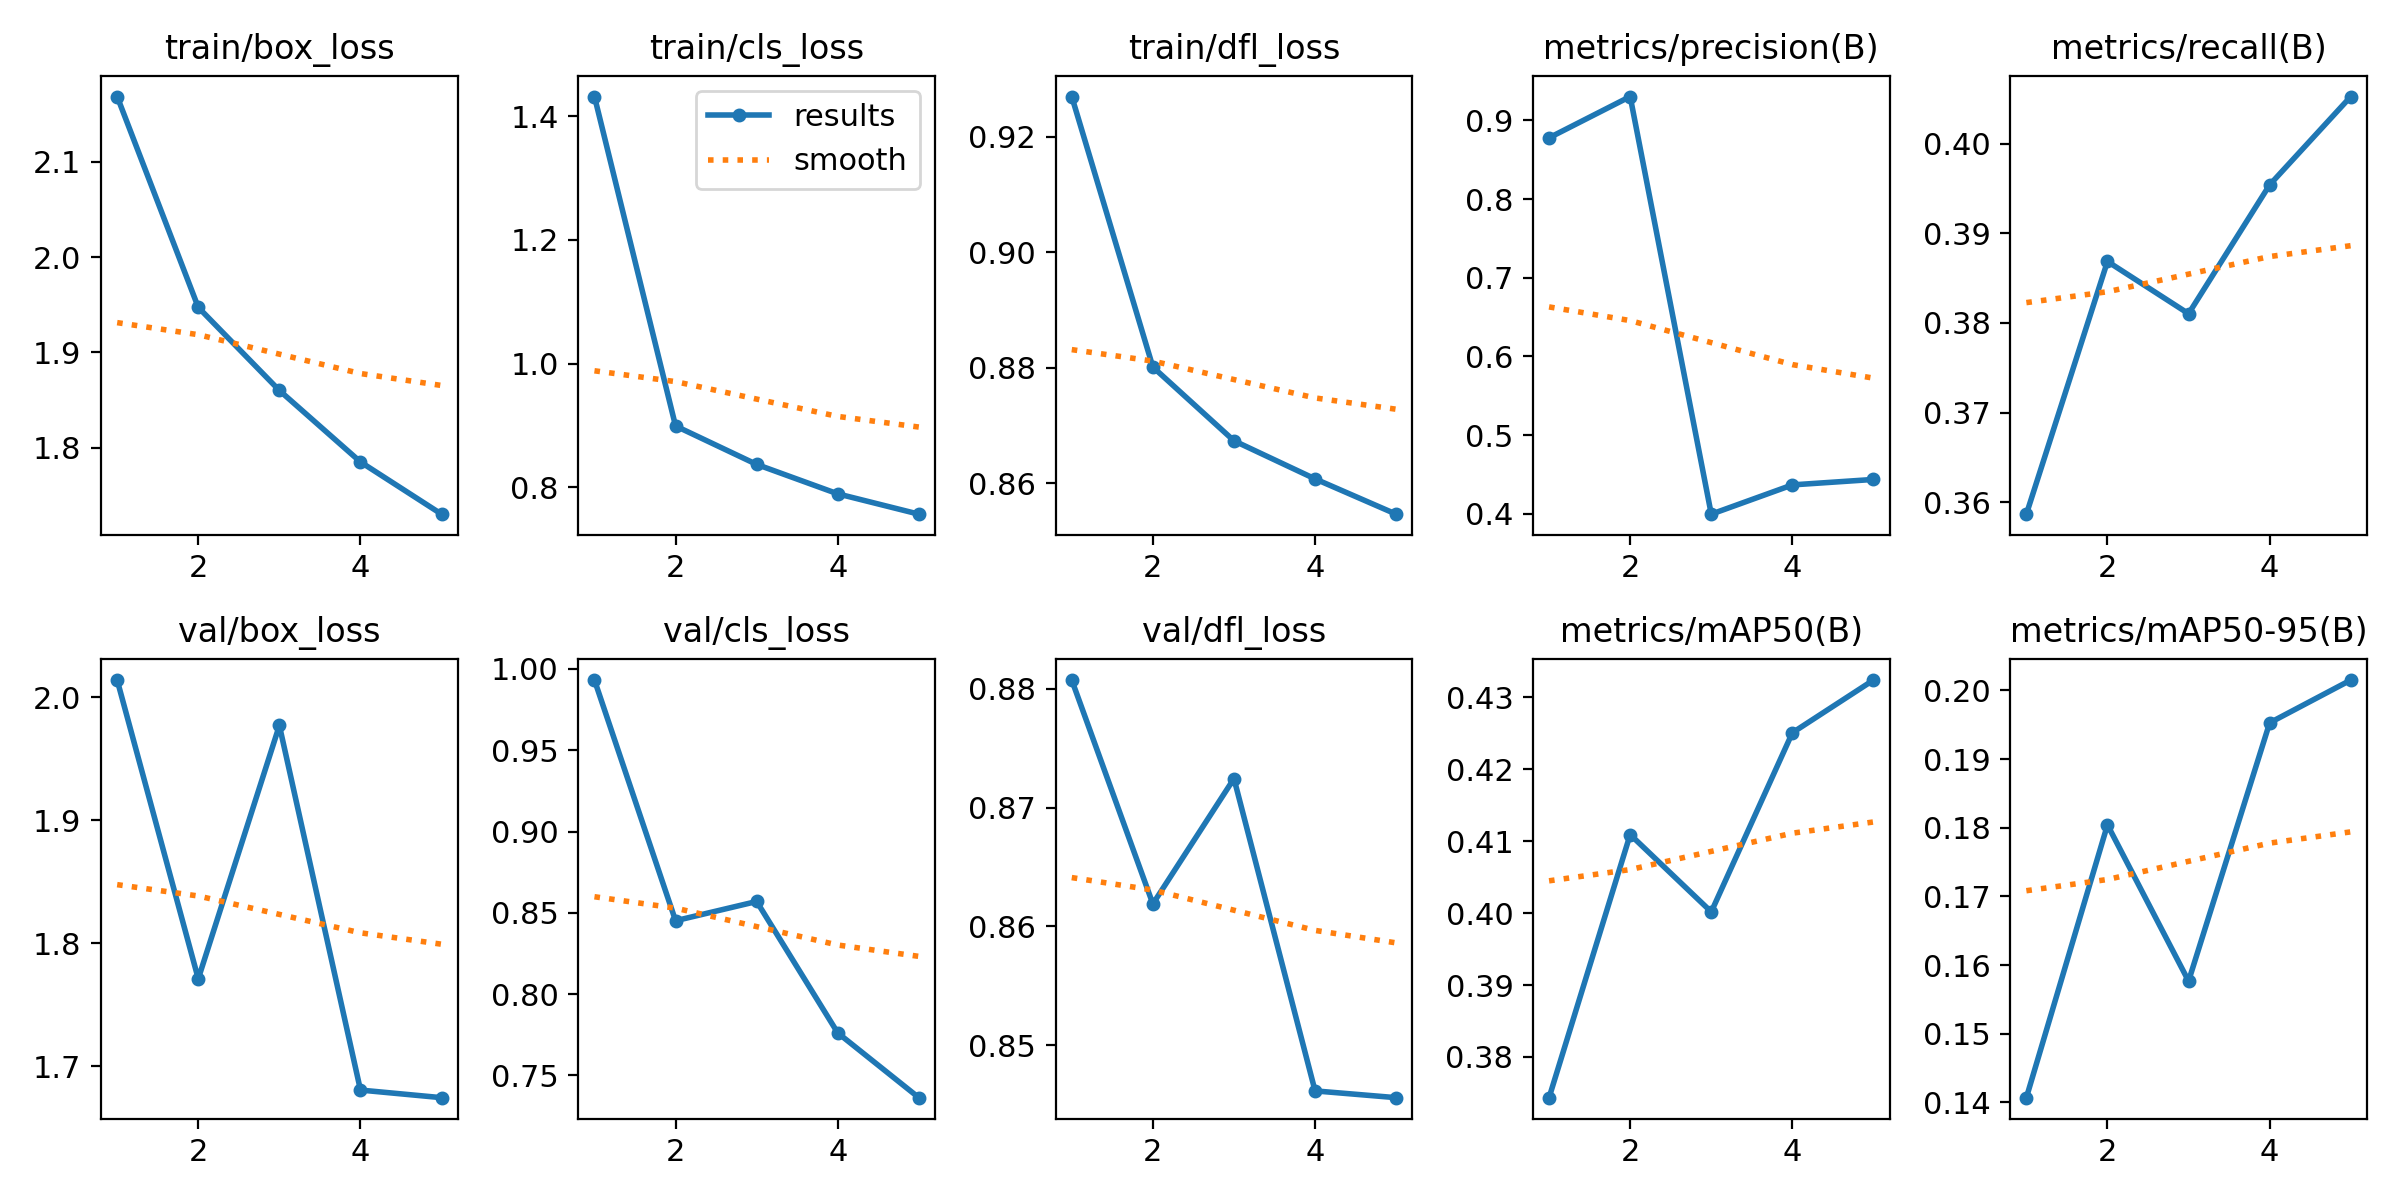

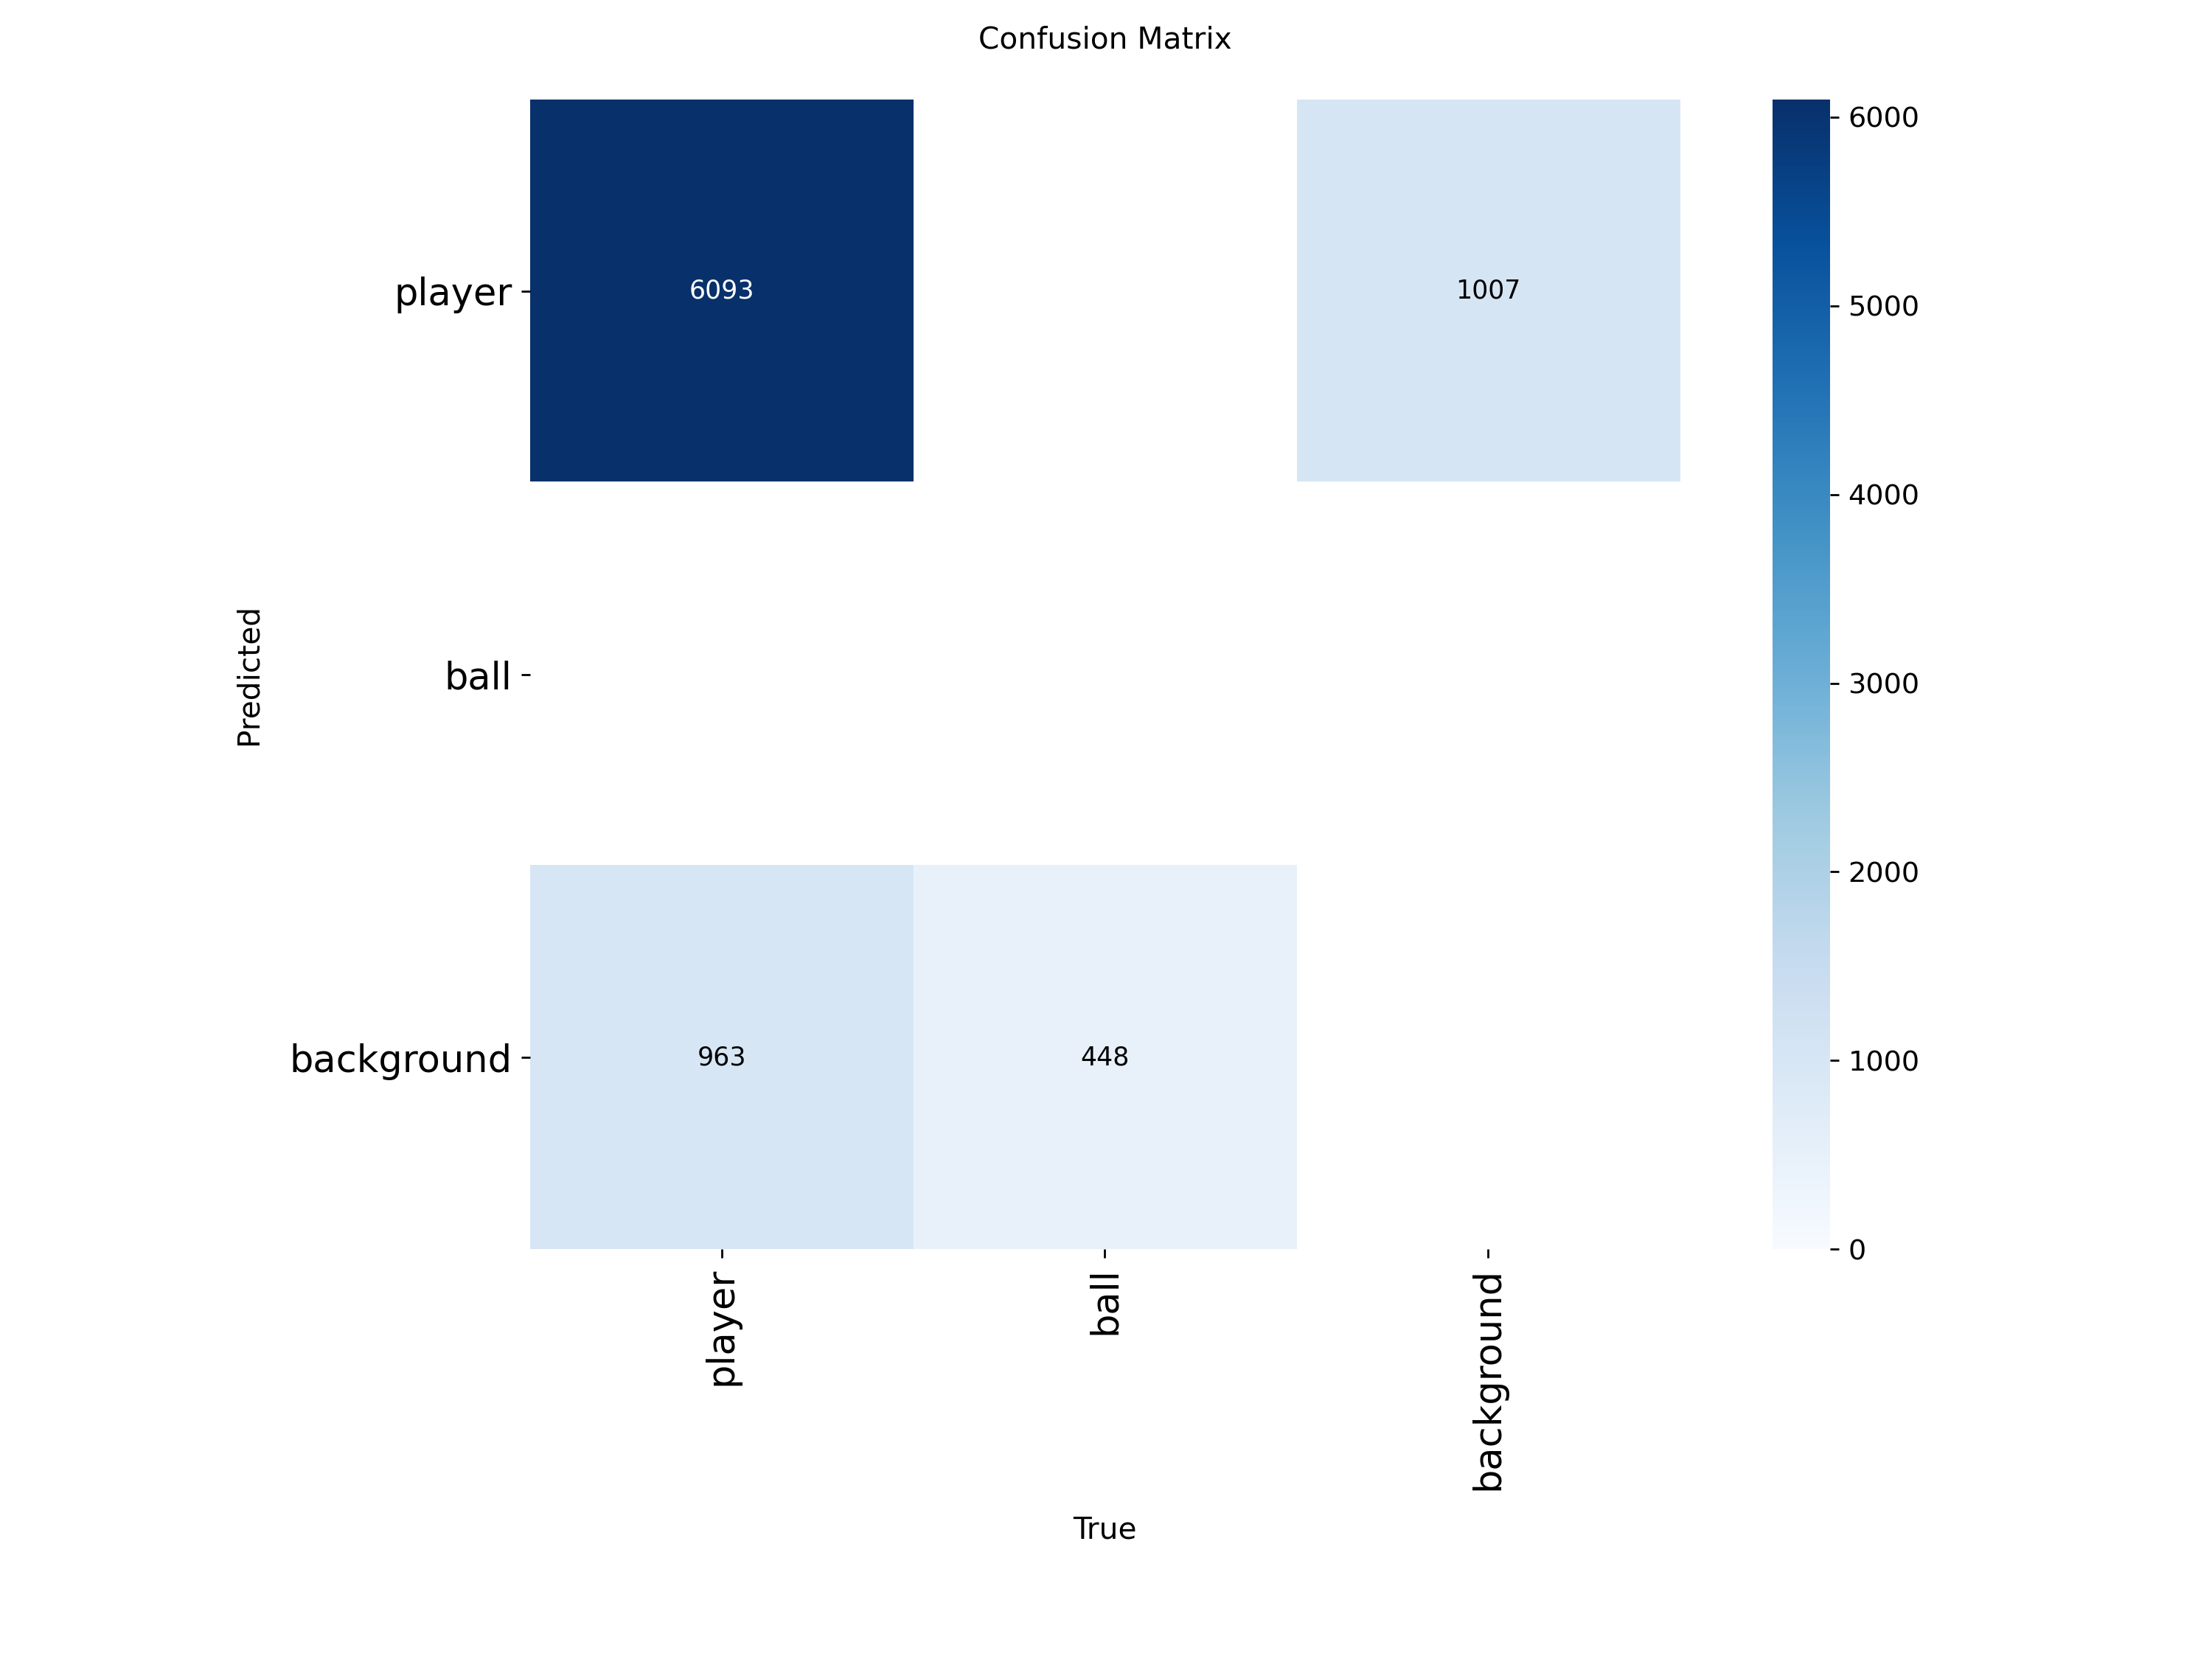

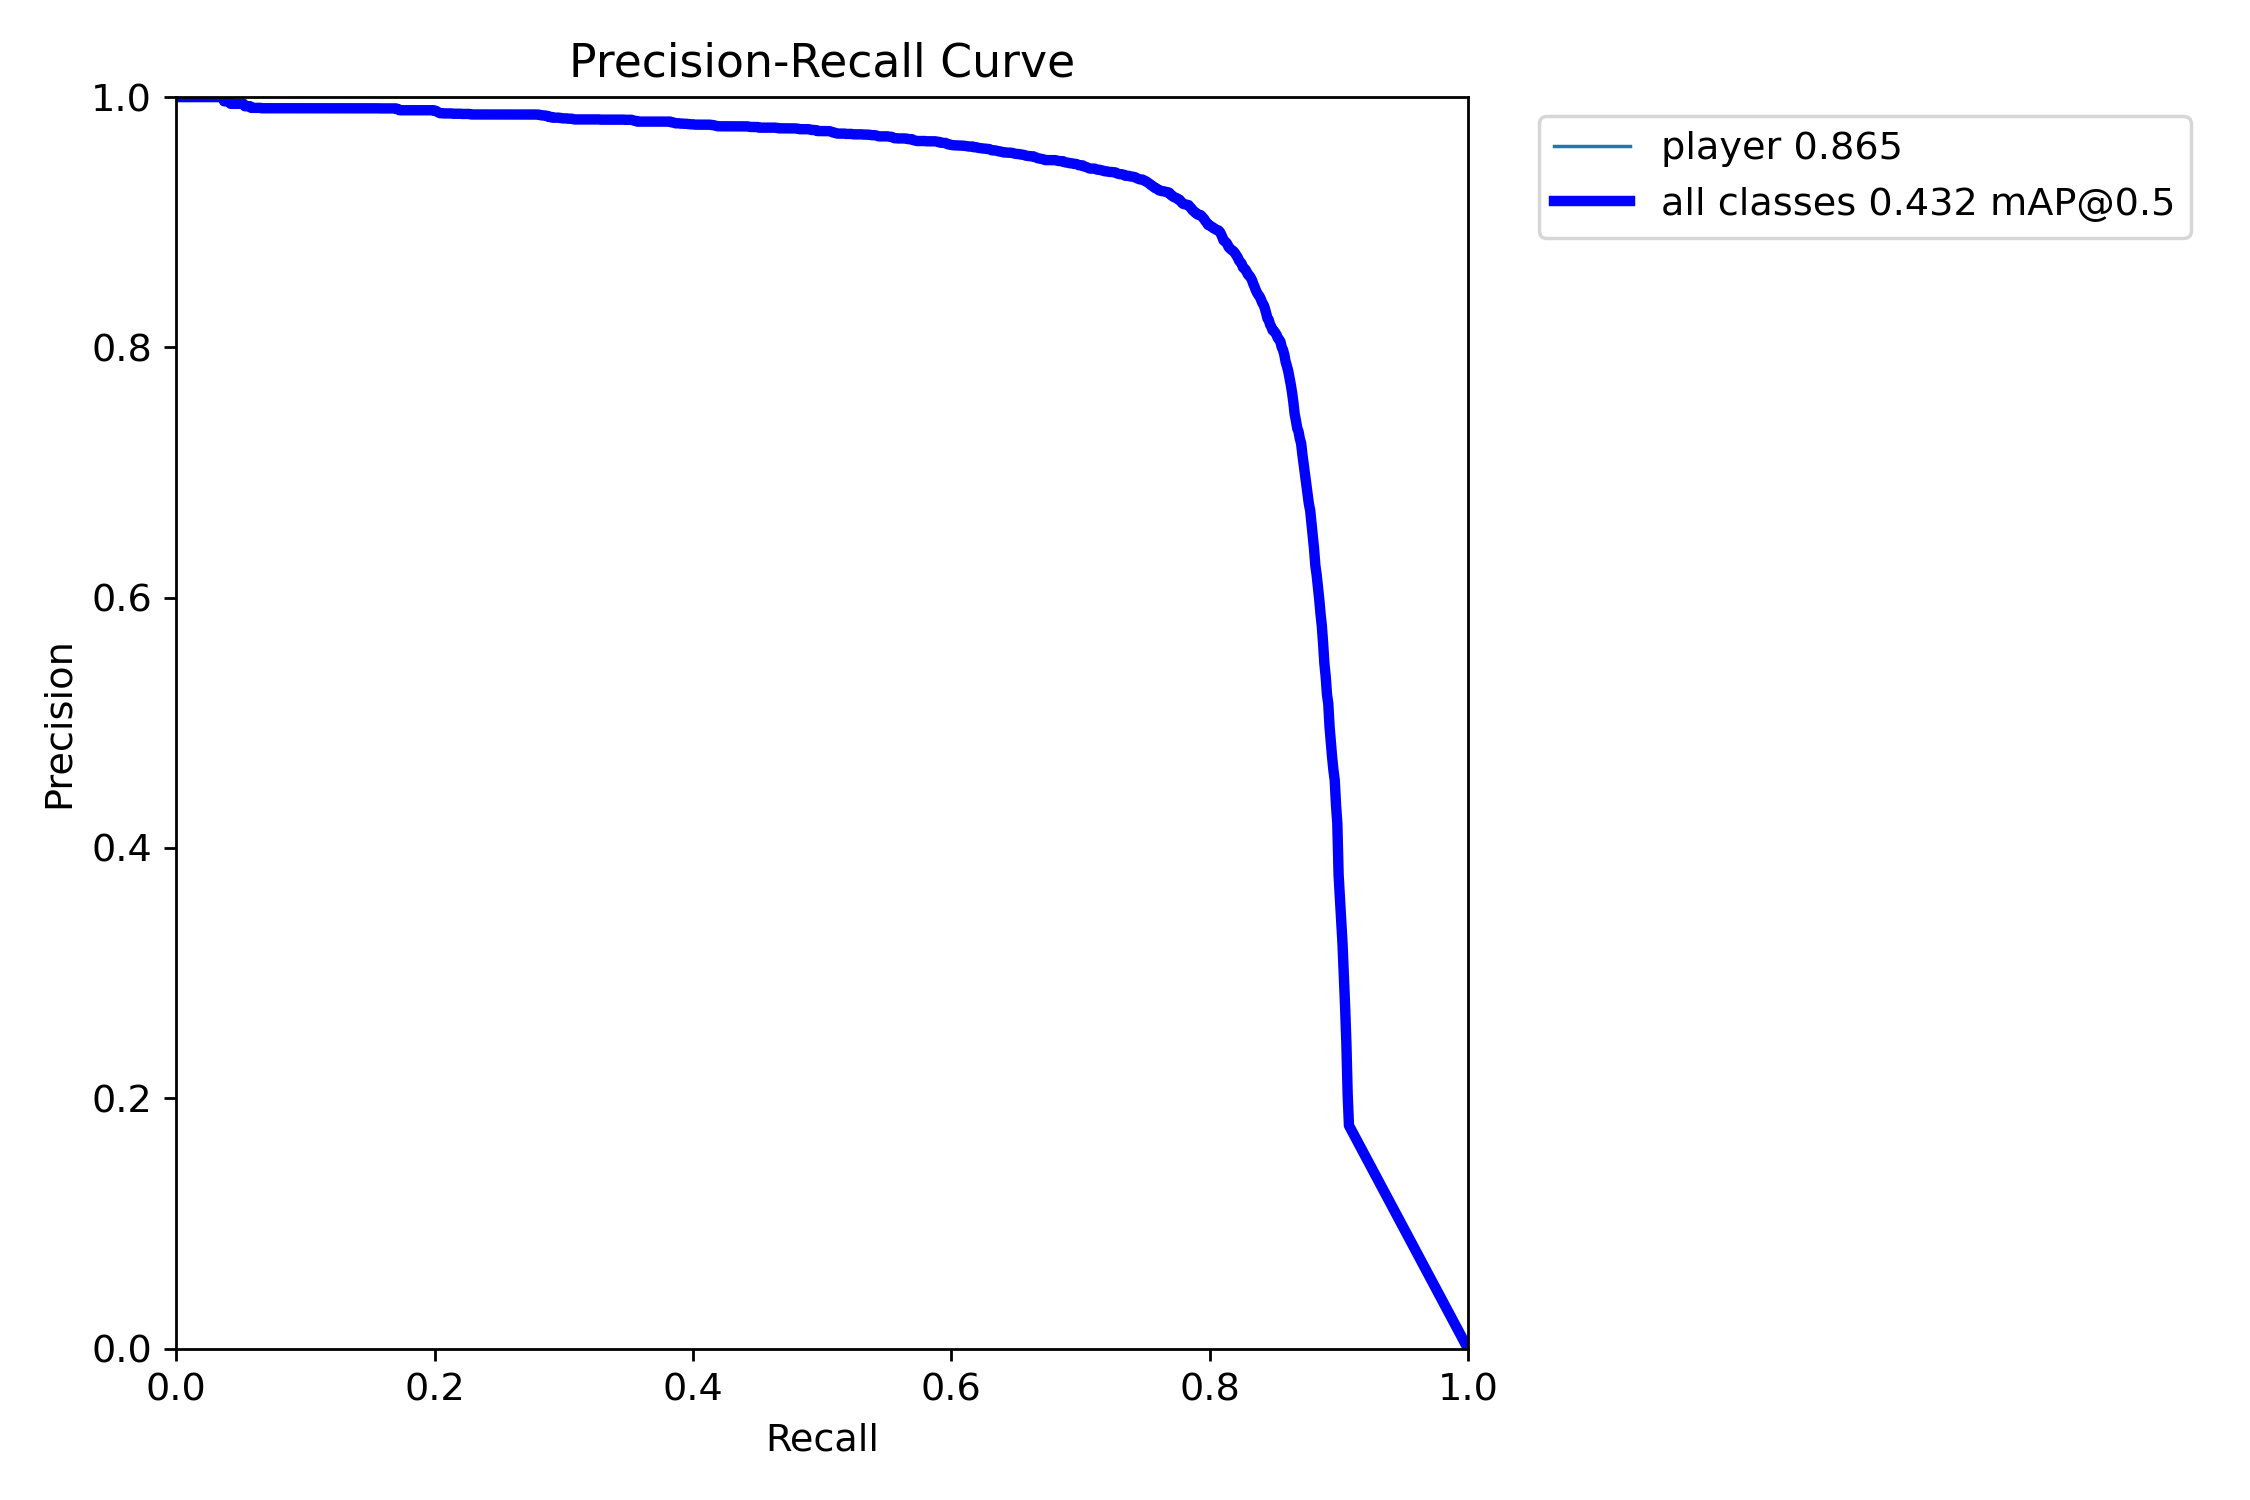

In [21]:
from IPython.display import Image, display
import os

display(Image(filename=f"{run_dir}/results.png"))             # pérdida y mAP vs época
display(Image(filename=f"{run_dir}/confusion_matrix.png"))    # matriz de confusión
display(Image(filename=f"{run_dir}/BoxPR_curve.png"))            # curvas Precision-Recall

In [32]:
!zip -r runs.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/val/ (stored 0%)
  adding: content/runs/detect/val2/ (stored 0%)
  adding: content/runs/detect/val2/BoxP_curve.png (deflated 17%)
  adding: content/runs/detect/val2/BoxF1_curve.png (deflated 16%)
  adding: content/runs/detect/val2/val_batch2_pred.jpg (deflated 9%)
  adding: content/runs/detect/val2/confusion_matrix_normalized.png (deflated 34%)
  adding: content/runs/detect/val2/confusion_matrix.png (deflated 33%)
  adding: content/runs/detect/val2/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs/detect/val2/val_batch1_labels.jpg (deflated 9%)
  adding: content/runs/detect/val2/val_batch1_pred.jpg (deflated 8%)
  adding: content/runs/detect/val2/BoxR_curve.png (deflated 15%)
  adding: content/runs/detect/val2/val_batch0_labels.jpg (deflated 9%)
  adding: content/runs/detect/val2/BoxPR_curve.png (deflated 20%)
  adding: content/runs/detect/val2/val_batch2_labels.jpg (defl

In [38]:
# Ajusta: tu modelo entrenado
MODEL_PATH = "/content/runs_soccer/yolo_cpu_fast3/weights/best.pt"  # cambia si tu run se llama distinto
model = YOLO(MODEL_PATH)

# Ajusta: secuencia a visualizar (img1)
SEQ_DIR = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-064/img1"

frames = sorted(glob(os.path.join(SEQ_DIR, "*.jpg")))
print("Frames:", len(frames), "Ej:", frames[:2])


Frames: 750 Ej: ['/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-064/img1/000001.jpg', '/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-064/img1/000002.jpg']


In [39]:
def iou_xyxy(a, b):
    # a, b: (x1,y1,x2,y2)
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0, inter_x2 - inter_x1)
    ih = max(0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0, ax2-ax1) * max(0, ay2-ay1)
    area_b = max(0, bx2-bx1) * max(0, by2-by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

class SimpleIOUTracker:
    def __init__(self, iou_th=0.3, max_age=15):
        self.iou_th = iou_th
        self.max_age = max_age
        self.next_id = 1
        self.tracks = {}  # id -> dict(bbox, age)

    def update(self, dets):
        """
        dets: list of dicts: {"bbox":(x1,y1,x2,y2), "conf":float}
        returns: list of dicts with {"id", "bbox", "conf"}
        """
        # envejecer tracks
        for tid in list(self.tracks.keys()):
            self.tracks[tid]["age"] += 1
            if self.tracks[tid]["age"] > self.max_age:
                del self.tracks[tid]

        assigned = set()
        outputs = []

        # Greedy matching: para cada det, buscar mejor track
        for det in dets:
            best_tid = None
            best_iou = 0.0
            for tid, tr in self.tracks.items():
                if tid in assigned:
                    continue
                i = iou_xyxy(det["bbox"], tr["bbox"])
                if i > best_iou:
                    best_iou = i
                    best_tid = tid

            if best_tid is not None and best_iou >= self.iou_th:
                # actualizar track
                self.tracks[best_tid]["bbox"] = det["bbox"]
                self.tracks[best_tid]["age"] = 0
                assigned.add(best_tid)
                outputs.append({"id": best_tid, **det})
            else:
                # nuevo track
                tid = self.next_id
                self.next_id += 1
                self.tracks[tid] = {"bbox": det["bbox"], "age": 0}
                assigned.add(tid)
                outputs.append({"id": tid, **det})

        return outputs


In [40]:
import os, cv2
from IPython.display import HTML

# Trackers separados por clase para evitar que el balón “robe” un ID de jugador
tracker_player = SimpleIOUTracker(iou_th=0.25, max_age=20)
tracker_ball   = SimpleIOUTracker(iou_th=0.10, max_age=10)  # balón cambia más rápido

CONF = 0.35
IMGSZ = 416     # en CPU suele ir más rápido que 640
FPS = 25
MAX_FRAMES = 400  # para demo rápida; sube si quieres

# Salida
out_path = "/content/snmot_preview_ids.mp4"

# Leer primer frame para tamaño
first = cv2.imread(frames[0])
H, W = first.shape[:2]
vw = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))

# (Opcional) nombres en tu YAML: 0=player 1=ball
names = {0: "player", 1: "ball"}

for idx, fp in enumerate(frames[:min(MAX_FRAMES, len(frames))]):
    img_bgr = cv2.imread(fp)
    if img_bgr is None:
        continue

    # YOLO (ultralytics trabaja bien con ruta o array)
    res = model.predict(img_bgr, conf=CONF, imgsz=IMGSZ, verbose=False)[0]

    dets_player = []
    dets_ball = []

    if res.boxes is not None and len(res.boxes) > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        conf = res.boxes.conf.cpu().numpy()

        for (x1,y1,x2,y2), c, cf in zip(xyxy, cls, conf):
            det = {"bbox": (float(x1),float(y1),float(x2),float(y2)), "conf": float(cf)}
            if c == 0:
                dets_player.append(det)
            elif c == 1:
                dets_ball.append(det)

    tracks_p = tracker_player.update(dets_player)
    tracks_b = tracker_ball.update(dets_ball)

    # Dibujar
    for tr in tracks_p:
        x1,y1,x2,y2 = map(int, tr["bbox"])
        tid = tr["id"]
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img_bgr, f"player ID {tid}", (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    for tr in tracks_b:
        x1,y1,x2,y2 = map(int, tr["bbox"])
        tid = tr["id"]
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), (0,0,255), 2)
        cv2.putText(img_bgr, f"ball ID {tid}", (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

    vw.write(img_bgr)

vw.release()
print("Video listo:", out_path, "size(bytes):", os.path.getsize(out_path))


Video listo: /content/snmot_preview_ids.mp4 size(bytes): 55056811


## Seguimiento Flujo optico

In [41]:
import os, cv2
import numpy as np
from glob import glob
from ultralytics import YOLO
from scipy.optimize import linear_sum_assignment


In [42]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1); inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2); inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    return inter / (area_a + area_b - inter + 1e-9)

lk_params = dict(
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

def shift_bbox_with_lk(prev_gray, gray, bbox_xyxy, max_pts=60):
    x1, y1, x2, y2 = map(int, bbox_xyxy)
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = max(x1+1, x2); y2 = max(y1+1, y2)

    roi = prev_gray[y1:y2, x1:x2]
    if roi.size == 0:
        return bbox_xyxy

    pts = cv2.goodFeaturesToTrack(roi, maxCorners=max_pts, qualityLevel=0.01, minDistance=7)
    if pts is None:
        return bbox_xyxy

    pts[:,0,0] += x1
    pts[:,0,1] += y1

    pts2, st, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, pts, None, **lk_params)
    if pts2 is None:
        return bbox_xyxy

    good1 = pts[st.flatten()==1]
    good2 = pts2[st.flatten()==1]
    if len(good1) < 5:
        return bbox_xyxy

    d = (good2 - good1).reshape(-1,2)
    dx, dy = np.median(d, axis=0)
    return (x1+dx, y1+dy, x2+dx, y2+dy)


In [43]:
class KalmanCenter:
    # Estado: [cx, cy, vx, vy]
    def __init__(self, cx, cy):
        self.x = np.array([[cx],[cy],[0.],[0.]], dtype=np.float32)
        self.F = np.array([[1,0,1,0],
                           [0,1,0,1],
                           [0,0,1,0],
                           [0,0,0,1]], dtype=np.float32)
        self.H = np.array([[1,0,0,0],
                           [0,1,0,0]], dtype=np.float32)
        self.P = np.eye(4, dtype=np.float32) * 300.0
        self.Q = np.eye(4, dtype=np.float32) * 3.0
        self.R = np.eye(2, dtype=np.float32) * 20.0

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return float(self.x[0]), float(self.x[1])

    def update(self, cx, cy):
        z = np.array([[cx],[cy]], dtype=np.float32)
        y = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4, dtype=np.float32) - K @ self.H) @ self.P


In [44]:
class Track:
    def __init__(self, tid, bbox, cls_id, conf):
        self.id = tid
        self.cls_id = cls_id
        self.bbox = bbox  # xyxy
        self.conf = conf
        cx = (bbox[0]+bbox[2])/2
        cy = (bbox[1]+bbox[3])/2
        self.kf = KalmanCenter(cx, cy)
        self.w = (bbox[2]-bbox[0])
        self.h = (bbox[3]-bbox[1])
        self.age = 0
        self.hits = 1

    def predict_kalman_bbox(self):
        cx, cy = self.kf.predict()
        x1 = cx - self.w/2
        y1 = cy - self.h/2
        x2 = cx + self.w/2
        y2 = cy + self.h/2
        return (x1,y1,x2,y2)

    def update(self, det_bbox, det_conf, ema_size=0.9):
        # update center
        cx = (det_bbox[0]+det_bbox[2])/2
        cy = (det_bbox[1]+det_bbox[3])/2
        self.kf.update(cx, cy)

        # update size (EMA)
        dw = (det_bbox[2]-det_bbox[0])
        dh = (det_bbox[3]-det_bbox[1])
        self.w = ema_size*self.w + (1-ema_size)*dw
        self.h = ema_size*self.h + (1-ema_size)*dh

        self.bbox = det_bbox
        self.conf = det_conf
        self.age = 0
        self.hits += 1

class OFKalmanTracker:
    def __init__(self, cls_id, iou_th=0.25, max_age=20, alpha=0.6):
        """
        alpha: peso de Kalman en la predicción final (0..1)
               pred_final = alpha*pred_kalman + (1-alpha)*pred_flow
        """
        self.cls_id = cls_id
        self.iou_th = iou_th
        self.max_age = max_age
        self.alpha = alpha
        self.tracks = []
        self.next_id = 1

    def step(self, dets, prev_gray=None, gray=None):
        """
        dets: list of dict {bbox:(x1,y1,x2,y2), conf:float}
        """
        # envejecer
        for tr in self.tracks:
            tr.age += 1
        self.tracks = [t for t in self.tracks if t.age <= self.max_age]

        # predicciones
        preds = []
        for tr in self.tracks:
            kal = tr.predict_kalman_bbox()

            if prev_gray is not None and gray is not None:
                flow = shift_bbox_with_lk(prev_gray, gray, tr.bbox, max_pts=60 if self.cls_id==0 else 20)
            else:
                flow = tr.bbox

            # combinar (Kalman + Flow)
            pk = np.array(kal, dtype=np.float32)
            pf = np.array(flow, dtype=np.float32)
            p = self.alpha*pk + (1-self.alpha)*pf
            preds.append(tuple(p.tolist()))

        # asociación Hungarian con costo 1-IoU (maximizar IoU)
        M = len(self.tracks)
        N = len(dets)
        if M > 0 and N > 0:
            cost = np.ones((M, N), dtype=np.float32)
            for i in range(M):
                for j in range(N):
                    cost[i,j] = 1.0 - iou_xyxy(preds[i], dets[j]["bbox"])
            ri, cj = linear_sum_assignment(cost)

            matched = []
            unmatched_tracks = set(range(M))
            unmatched_dets = set(range(N))

            for i, j in zip(ri, cj):
                iou = 1.0 - cost[i,j]
                if iou >= self.iou_th:
                    matched.append((i,j))
                    unmatched_tracks.discard(i)
                    unmatched_dets.discard(j)

            # update tracks
            for i, j in matched:
                self.tracks[i].update(dets[j]["bbox"], dets[j]["conf"])
                # opcional: reemplazar bbox por predicción suavizada (si quieres menos jitter)
                # self.tracks[i].bbox = preds[i]

            # crear nuevos tracks
            for j in unmatched_dets:
                tid = self.next_id
                self.next_id += 1
                self.tracks.append(Track(tid, dets[j]["bbox"], self.cls_id, dets[j]["conf"]))

        else:
            # si no hay tracks, inicializar
            for d in dets:
                tid = self.next_id
                self.next_id += 1
                self.tracks.append(Track(tid, d["bbox"], self.cls_id, d["conf"]))

        return self.tracks


In [63]:
MODEL_PATH = "/content/runs_soccer/yolo_cpu_fast3/weights/best.pt"  # tu best.pt
SEQ_DIR = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-064/img1"

model = YOLO(MODEL_PATH)
frames = sorted(glob(os.path.join(SEQ_DIR, "*.jpg")))

# Trackers por clase
tracker_player = OFKalmanTracker(cls_id=0, iou_th=0.25, max_age=25, alpha=0.6)
tracker_ball   = OFKalmanTracker(cls_id=1, iou_th=0.10, max_age=10, alpha=0.3)  # ball: más peso al flow

CONF_PLAYER = 0.35
CONF_BALL   = 0.20  # balón suele requerir conf menor
IMGSZ = 320
FPS = 25
MAX_FRAMES = 500  # demo rápida


In [64]:
from IPython.display import HTML

out_path = "/content/preview_OF_Kalman.mp4"

first = cv2.imread(frames[0])
H, W = first.shape[:2]
vw = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))

prev_gray = None

for fp in frames[:min(MAX_FRAMES, len(frames))]:
    img = cv2.imread(fp)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # YOLO detecciones
    res = model.predict(img, imgsz=IMGSZ, conf=min(CONF_PLAYER, CONF_BALL), verbose=False)[0]

    dets_p, dets_b = [], []
    if res.boxes is not None and len(res.boxes) > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        conf = res.boxes.conf.cpu().numpy()

        for (x1,y1,x2,y2), c, cf in zip(xyxy, cls, conf):
            det = {"bbox": (float(x1),float(y1),float(x2),float(y2)), "conf": float(cf)}
            if c == 0 and cf >= CONF_PLAYER:
                dets_p.append(det)
            elif c == 1 and cf >= CONF_BALL:
                dets_b.append(det)

    # tracking step (Kalman + Optical Flow)
    tracks_p = tracker_player.step(dets_p, prev_gray, gray)
    tracks_b = tracker_ball.step(dets_b, prev_gray, gray)

    # dibujar
    for tr in tracks_p:
        x1,y1,x2,y2 = map(int, tr.bbox)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, f"P {tr.id}", (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    for tr in tracks_b:
        x1,y1,x2,y2 = map(int, tr.bbox)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,0,255), 2)
        cv2.putText(img, f"B {tr.id}", (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

    vw.write(img)
    prev_gray = gray

vw.release()

HTML(f"""
<video width="720" controls>
  <source src="{out_path}" type="video/mp4">
</video>
""")


/tmp/ipython-input-1740474894.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self.x[0]), float(self.x[1])


## Metricas

In [51]:
!pip -q install motmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 1.9 MB/s eta 0:00:00


In [56]:
import configparser
import motmetrics as mm
import pandas as pd

In [65]:
SEQ_ROOT = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-064"
IMG_DIR  = os.path.join(SEQ_ROOT, "img1")
GT_PATH  = os.path.join(SEQ_ROOT, "gt", "gt.txt")
GAMEINFO = os.path.join(SEQ_ROOT, "gameinfo.ini")

MODEL_PATH = "/content/runs_soccer/yolo_cpu_fast3/weights/best.pt"  # tu best.pt


In [66]:
def get_tracklet_roles(gameinfo_path):
    cfg = configparser.ConfigParser()
    cfg.read(gameinfo_path)
    roles = {}
    for k, v in cfg["Sequence"].items():
        if not k.startswith("trackletid_"):
            continue
        tid = int(k.split("_")[1])
        main_role = v.split(";")[0].strip().lower().split()[0]  # player/goalkeeper/referee/ball
        roles[tid] = main_role
    return roles

track_roles = get_tracklet_roles(GAMEINFO)


In [67]:
gt = pd.read_csv(
    GT_PATH, header=None,
    names=["frame","id","x","y","w","h","conf","x2","y2","z"]
)
gt = gt[gt["conf"] > 0].copy()

gt["role"] = gt["id"].map(track_roles)
gt_player = gt[gt["role"].isin(["player", "goalkeeper"])].copy()
gt_ball   = gt[gt["role"].isin(["ball"])].copy()

print("GT player rows:", len(gt_player), "GT ball rows:", len(gt_ball))


GT player rows: 13872 GT ball rows: 590


In [68]:
from scipy.optimize import linear_sum_assignment

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
    inter = iw*ih
    area_a = max(0, ax2-ax1)*max(0, ay2-ay1)
    area_b = max(0, bx2-bx1)*max(0, by2-by1)
    return inter/(area_a+area_b-inter+1e-9)

class SimpleHungarianTracker:
    def __init__(self, iou_th=0.25, max_age=20):
        self.iou_th=iou_th
        self.max_age=max_age
        self.next_id=1
        self.tracks=[]  # list of dict: id,bbox,age,conf

    def step(self, dets):
        # age tracks
        for t in self.tracks:
            t["age"] += 1
        self.tracks = [t for t in self.tracks if t["age"] <= self.max_age]

        M, N = len(self.tracks), len(dets)
        if M>0 and N>0:
            cost = np.ones((M,N), dtype=np.float32)
            for i,t in enumerate(self.tracks):
                for j,d in enumerate(dets):
                    cost[i,j] = 1.0 - iou_xyxy(t["bbox"], d["bbox"])
            ri,cj = linear_sum_assignment(cost)

            matched=set()
            used_d=set()
            for i,j in zip(ri,cj):
                iou = 1.0 - cost[i,j]
                if iou >= self.iou_th:
                    self.tracks[i]["bbox"] = dets[j]["bbox"]
                    self.tracks[i]["conf"] = dets[j]["conf"]
                    self.tracks[i]["age"] = 0
                    matched.add(i)
                    used_d.add(j)

            # new tracks
            for j,d in enumerate(dets):
                if j in used_d:
                    continue
                self.tracks.append({"id": self.next_id, "bbox": d["bbox"], "conf": d["conf"], "age": 0})
                self.next_id += 1
        else:
            for d in dets:
                self.tracks.append({"id": self.next_id, "bbox": d["bbox"], "conf": d["conf"], "age": 0})
                self.next_id += 1

        return self.tracks


In [69]:
model = YOLO(MODEL_PATH)
frames = sorted(glob(os.path.join(IMG_DIR, "*.jpg")))

# trackers separados por clase
trk_p = SimpleHungarianTracker(iou_th=0.25, max_age=25)  # player
trk_b = SimpleHungarianTracker(iou_th=0.10, max_age=10)  # ball

CONF_PLAYER = 0.35
CONF_BALL   = 0.20
IMGSZ = 320

pred_rows_player = []
pred_rows_ball = []

for fp in frames:
    frame_id = int(os.path.basename(fp).split(".")[0])  # 000123 -> 123
    img = cv2.imread(fp)

    res = model.predict(img, imgsz=IMGSZ, conf=min(CONF_PLAYER, CONF_BALL), verbose=False)[0]

    dets_p, dets_b = [], []
    if res.boxes is not None and len(res.boxes) > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        conf = res.boxes.conf.cpu().numpy()

        for (x1,y1,x2,y2), c, cf in zip(xyxy, cls, conf):
            bbox = (float(x1),float(y1),float(x2),float(y2))
            if c == 0 and cf >= CONF_PLAYER:
                dets_p.append({"bbox": bbox, "conf": float(cf)})
            elif c == 1 and cf >= CONF_BALL:
                dets_b.append({"bbox": bbox, "conf": float(cf)})

    tracks_p = trk_p.step(dets_p)
    tracks_b = trk_b.step(dets_b)

    for t in tracks_p:
        x1,y1,x2,y2 = t["bbox"]
        pred_rows_player.append([frame_id, t["id"], x1, y1, x2-x1, y2-y1, t["conf"]])

    for t in tracks_b:
        x1,y1,x2,y2 = t["bbox"]
        pred_rows_ball.append([frame_id, t["id"], x1, y1, x2-x1, y2-y1, t["conf"]])

pred_player = pd.DataFrame(pred_rows_player, columns=["frame","id","x","y","w","h","conf"])
pred_ball   = pd.DataFrame(pred_rows_ball,   columns=["frame","id","x","y","w","h","conf"])

print("Pred player rows:", len(pred_player), "Pred ball rows:", len(pred_ball))


Pred player rows: 22401 Pred ball rows: 0


In [70]:
def motmetrics_from_dfs(gt_df, pr_df, iou_match=0.5):
    """
    gt_df / pr_df: columns frame,id,x,y,w,h
    iou_match: umbral IoU para considerar match
    """
    acc = mm.MOTAccumulator(auto_id=True)

    all_frames = sorted(set(gt_df["frame"].unique()).union(set(pr_df["frame"].unique())))
    for f in all_frames:
        g = gt_df[gt_df["frame"] == f]
        p = pr_df[pr_df["frame"] == f]

        gt_ids = g["id"].tolist()
        pr_ids = p["id"].tolist()

        gt_boxes = g[["x","y","w","h"]].to_numpy()
        pr_boxes = p[["x","y","w","h"]].to_numpy()

        if len(gt_ids)==0 and len(pr_ids)==0:
            acc.update([], [], [])
            continue

        # distancia = 1 - IoU (NaN si IoU < iou_match)
        D = np.full((len(gt_ids), len(pr_ids)), np.nan, dtype=np.float32)

        for i in range(len(gt_ids)):
            gx,gy,gw,gh = gt_boxes[i]
            ga = (gx,gy,gx+gw,gy+gh)
            for j in range(len(pr_ids)):
                px,py,pw,ph = pr_boxes[j]
                pa = (px,py,px+pw,py+ph)
                iou = iou_xyxy(ga, pa)
                if iou >= iou_match:
                    D[i,j] = 1.0 - iou

        acc.update(gt_ids, pr_ids, D)

    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=["mota","idf1","num_switches","precision","recall","num_false_positives","num_misses"], name="SNMOT-062")
    return summary

# para players (player+goalkeeper)
summary_p = motmetrics_from_dfs(gt_player[["frame","id","x","y","w","h"]], pred_player[["frame","id","x","y","w","h"]], iou_match=0.5)

# para ball (umbral más bajo suele ser razonable por objeto pequeño)
summary_b = motmetrics_from_dfs(gt_ball[["frame","id","x","y","w","h"]], pred_ball[["frame","id","x","y","w","h"]], iou_match=0.3)

print("=== PLAYERS (IoU>=0.5) ===")
display(summary_p)

print("=== BALL (IoU>=0.3) ===")
display(summary_b)


=== PLAYERS (IoU>=0.5) ===


,mota,idf1,num_switches,precision,recall,num_false_positives,num_misses
SNMOT-062,-0.042748,0.217297,708,0.502567,0.811563,11143,2614


=== BALL (IoU>=0.3) ===


,mota,idf1,num_switches,precision,recall,num_false_positives,num_misses
SNMOT-062,0.0,0.0,0,NaN,0.0,0,590
